In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 生成100个假数据：y = 2x + 1 + 噪声
np.random.seed(42)
m = 100
X = np.random.randn(m, 1)
y = 2 * X + 1 + np.random.randn(m, 1) * 0.5

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 1)
y shape: (100, 1)


In [20]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/9.3 MB 624.5 kB/s eta 0:00:14
Resuming download matplotlib-3.11.1-cp313-cp313-macosx_11_0_arm64.whl (1.0 MB/9.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 341.8 kB/s  0:00:24 eta 0:00:010:01:04
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 36.9 kB/s  0:01:028.6 kB/s eta 0:00:07:12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 722.8 kB/s  0:00:069.9 kB/s eta 0:00:01:02
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ourpy]


In [22]:
import matplotlib.pyplot as plt
print("matplotlib 已安装")



matplotlib 已安装


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子，让每次结果一样（方便验证）
np.random.seed(42)

# 生成 100 个样本，1 个特征
m = 100
X = np.random.randn(m, 1)        # shape: (100, 1)，100行1列

# 真实规律：y = 2x + 1 + 噪声
# 噪声模拟真实世界的测量误差
true_w = 2
true_b = 1
noise = np.random.randn(m, 1) * 0.5

y = true_w * X + true_b + noise   # shape: (100, 1)

print("X shape:", X.shape)        # (100, 1)
print("y shape:", y.shape)        # (100, 1)
print("前5个样本:\n", np.hstack([X[:5], y[:5]]))


X shape: (100, 1)
y shape: (100, 1)
前5个样本:
 [[ 0.49671415  1.28574293]
 [-0.1382643   0.51314874]
 [ 0.64768854  2.12401982]
 [ 1.52302986  3.64492108]
 [-0.23415337  0.45105039]]


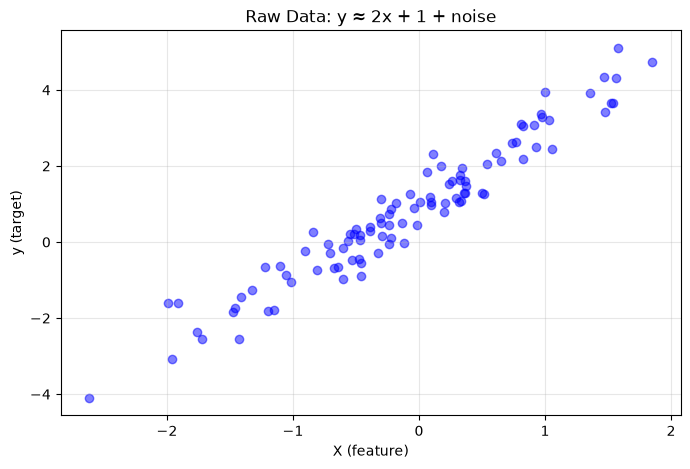

In [25]:
# 画散点图：看看这些点是不是大致沿一条直线分布
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5, color='blue')
plt.xlabel("X (feature)")
plt.ylabel("y (target)")
plt.title("Raw Data: y ≈ 2x + 1 + noise")
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
# 关键步骤：给 X 加一列 1，把偏置 b 也放进矩阵运算
# 原来 X 是 (100, 1)，加一列 1 后变成 (100, 2)
# 第一列是 1，对应偏置 b；第二列是原始 x，对应权重 w

X_b = np.c_[np.ones((m, 1)), X]    # shape: (100, 2)
print("X_b shape:", X_b.shape)
print("X_b 前3行：\n", X_b[:3])

# 正规方程：w_best = (X_b^T · X_b)^(-1) · X_b^T · y
# 逐行拆解，方便理解每一步的 shape

X_b_T = X_b.T                      # shape: (2, 100)，转置
A = X_b_T @ X_b                    # shape: (2, 2)，X_b^T · X_b
A_inv = np.linalg.inv(A)           # shape: (2, 2)，求逆矩阵
B = X_b_T @ y                      # shape: (2, 1)，X_b^T · y
w_best = A_inv @ B                 # shape: (2, 1)，最优参数

# w_best[0] 是 b，w_best[1] 是 w
print(f"\n学出来的参数：")
print(f"b (偏置) = {w_best[0][0]:.4f}  (真实值: {true_b})")
print(f"w (权重) = {w_best[1][0]:.4f}  (真实值: {true_w})")

X_b shape: (100, 2)
X_b 前3行：
 [[ 1.          0.49671415]
 [ 1.         -0.1382643 ]
 [ 1.          0.64768854]]

学出来的参数：
b (偏置) = 1.0037  (真实值: 1)
w (权重) = 1.9284  (真实值: 2)


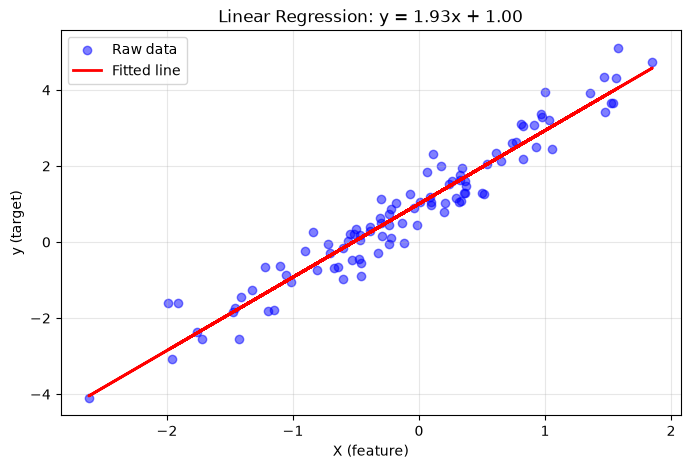

MSE Loss: 0.2209
RMSE: 0.4700


In [27]:
# 用学出来的参数做预测：y_pred = X_b · w_best
y_pred = X_b @ w_best              # shape: (100, 1)

# 画图：原始点 + 拟合红线
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5, color='blue', label='Raw data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Fitted line')
plt.xlabel("X (feature)")
plt.ylabel("y (target)")
plt.title(f"Linear Regression: y = {w_best[1][0]:.2f}x + {w_best[0][0]:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 计算 MSE（均方误差）：预测值和真实值差的平方的平均
mse = np.mean((y_pred - y) ** 2)
print(f"MSE Loss: {mse:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")

In [28]:
def linear_regression_normal_eq(X, y):
    """
    用正规方程求解线性回归。
    
    参数:
        X: np.ndarray, shape (m, n) —— m个样本，n个特征
        y: np.ndarray, shape (m, 1) —— m个标签
    
    返回:
        w: np.ndarray, shape (n+1, 1) —— 包含偏置b和权重w
    """
    m = len(X)
    X_b = np.c_[np.ones((m, 1)), X]   # 加一列1，shape (m, n+1)
    w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    return w

# 测试封装好的函数
w = linear_regression_normal_eq(X, y)
print(f"封装函数测试结果: b={w[0][0]:.4f}, w={w[1][0]:.4f}")

封装函数测试结果: b=1.0037, w=1.9284


In [29]:
# 测试：如果有2个特征，还能不能工作？
# 生成新数据：y = 3*x1 + 2*x2 + 5 + 噪声

np.random.seed(123)
m = 100
X2 = np.random.randn(m, 2)                    # 2个特征
true_w2 = np.array([[3], [2]])
true_b2 = 5
y2 = X2 @ true_w2 + true_b2 + np.random.randn(m, 1) * 0.5

w2 = linear_regression_normal_eq(X2, y2)
print(f"多特征测试结果:")
print(f"b = {w2[0][0]:.4f}  (真实值: {true_b2})")
print(f"w1 = {w2[1][0]:.4f}  (真实值: 3)")
print(f"w2 = {w2[2][0]:.4f}  (真实值: 2)")

多特征测试结果:
b = 4.9422  (真实值: 5)
w1 = 3.0520  (真实值: 3)
w2 = 1.9723  (真实值: 2)


In [4]:
##自己尝试
import numpy as np 
import matplotlib.pyplot as plt

np.random.seed(42)
m=100
X=np.random.randn(m,1)
true_w=2
true_b=1
noise= np.random.randn(m,1) * 0.5
y= true_w * X + true_b * X +noise
print("X shape:",X.shape)
print("y shape:",y.shape)
print("前五个样本:\n",np.hstack([X[:5],y[:5]]))

X shape: (100, 1)
y shape: (100, 1)
前五个样本:
 [[ 0.49671415  0.78245709]
 [-0.1382643  -0.62511556]
 [ 0.64768854  1.77170836]
 [ 1.52302986  4.16795093]
 [-0.23415337 -0.78310298]]


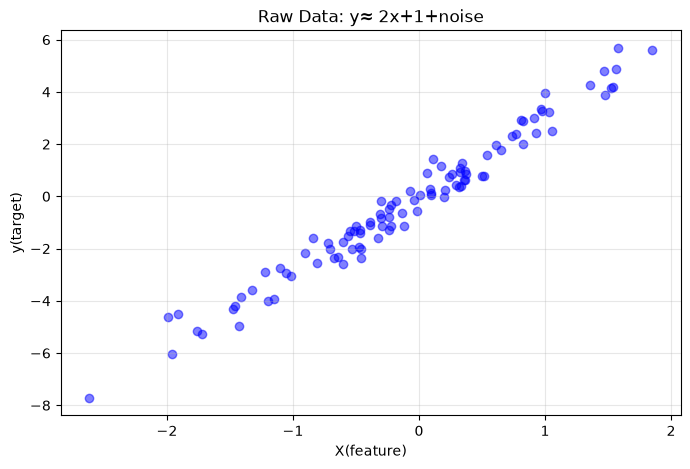

In [36]:
plt.figure(figsize=(8,5))
plt.scatter(X,y,alpha=0.5,color='blue')
plt.xlabel("X(feature)")
plt.ylabel("y(target)")
plt.title("Raw Data: y≈ 2x+1+noise")
plt.grid(True,alpha=0.3)
plt.show()

In [9]:

X_b = np.c_[np.ones((m,1)),X]
print("X_b shape:",X_b.shape)
print("X_b 前3行:\n",X_b[:3])

X_b_T=X_b.T
A =X_b_T@ X_b
A_inv =np.linalg.inv(A)
B=X_b_T @ y
w_best= A_inv @ B

print(f"\n选出来的参数：")
print(f"b(偏置)={w_best[0][0]:.4f} (真实值：{true_b})")
print(f"w(权重)={w_best[1][0]:.4f} (真实值:{true_w})")


X_b shape: (100, 2)
X_b 前3行:
 [[ 1.          0.49671415]
 [ 1.         -0.1382643 ]
 [ 1.          0.64768854]]

选出来的参数：
b(偏置)=0.0037 (真实值：1)
w(权重)=2.9284 (真实值:2)
